In [21]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Data and initial EDA

In [22]:
df = pd.read_csv("../data/IMDB_Dataset.csv")

In [23]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [25]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [26]:
from src.preprocessing import clean_text

df = clean_text(df)

df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


In [27]:
# Check first review to confirm it works
df['review'][0]

'one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty picture

#### Encode Sentiment

In [28]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [29]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1
...,...,...
49995,i thought this movie did a down right good job...,1
49996,bad plot bad dialogue bad acting idiotic direc...,0
49997,i am a catholic taught in parochial elementary...,0
49998,im going to have to disagree with the previous...,0


#### Split the data

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, stratify=df['sentiment'])

#### Instantiate TF-IDF and fit

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf.fit(X_train)

# Transform both splits
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


#### Train Baseline logisitic regression classifier on transformed Numerical TF-IDF data

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [52]:
y_pred_lr = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



#### Fit and Predict with Linear SVM

In [53]:
from sklearn.svm import LinearSVC

svc = LinearSVC()
svc.fit(X_train_tfidf, y_train)

y_pred_SVC = svc.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_SVC))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      5000
           1       0.90      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



### Train Transformer (DistilBERT) for classification

In [41]:
from transformers import pipeline
import torch
classifier = pipeline("sentiment-analysis", truncation=True)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [44]:
output = classifier(X_test[:1000].tolist())
output



[{'label': 'NEGATIVE', 'score': 0.9996106028556824},
 {'label': 'NEGATIVE', 'score': 0.9997021555900574},
 {'label': 'POSITIVE', 'score': 0.9994582533836365},
 {'label': 'NEGATIVE', 'score': 0.5266426801681519},
 {'label': 'POSITIVE', 'score': 0.9963390827178955},
 {'label': 'POSITIVE', 'score': 0.9992105960845947},
 {'label': 'POSITIVE', 'score': 0.9915607571601868},
 {'label': 'NEGATIVE', 'score': 0.9882400035858154},
 {'label': 'NEGATIVE', 'score': 0.9957054257392883},
 {'label': 'POSITIVE', 'score': 0.9855578541755676},
 {'label': 'NEGATIVE', 'score': 0.9997621178627014},
 {'label': 'POSITIVE', 'score': 0.9823564291000366},
 {'label': 'NEGATIVE', 'score': 0.9968138337135315},
 {'label': 'POSITIVE', 'score': 0.9980767965316772},
 {'label': 'NEGATIVE', 'score': 0.5391212701797485},
 {'label': 'POSITIVE', 'score': 0.9988859295845032},
 {'label': 'POSITIVE', 'score': 0.9201316833496094},
 {'label': 'POSITIVE', 'score': 0.9997755885124207},
 {'label': 'POSITIVE', 'score': 0.999573409557

#### Extract lebels and map to 1/0

In [ ]:
labels = [1 if x['label'] == 'POSITIVE' else 0 for x in output]

[0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [51]:
print(classification_report(labels, y_test[:1000]))

              precision    recall  f1-score   support

           0       0.96      0.79      0.87       590
           1       0.76      0.96      0.85       410

    accuracy                           0.86      1000
   macro avg       0.86      0.87      0.86      1000
weighted avg       0.88      0.86      0.86      1000



### Visualization

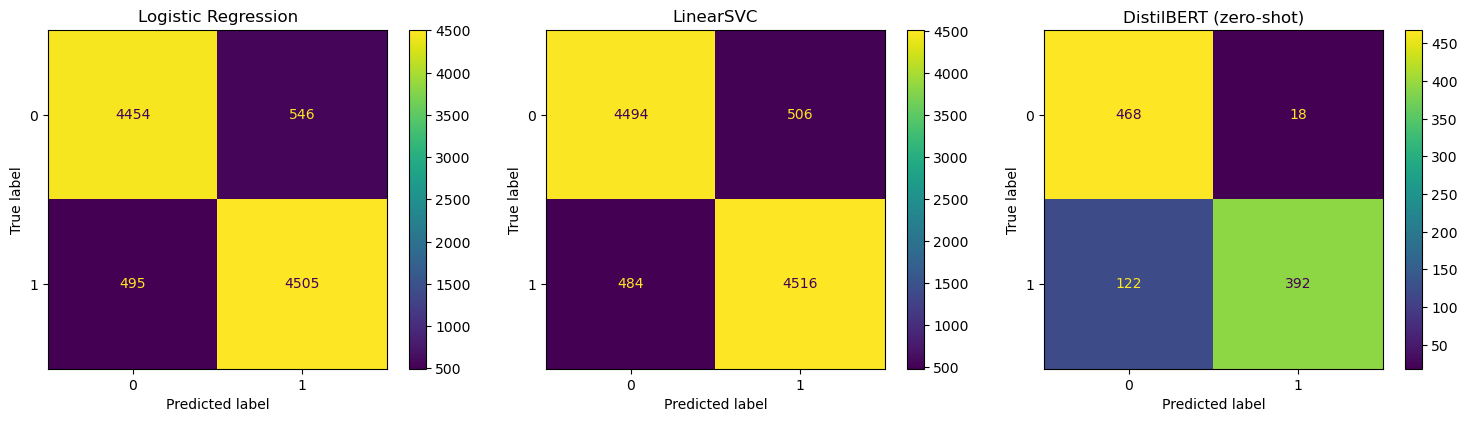

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_SVC)).plot(ax=axes[1])
axes[1].set_title('LinearSVC')

ConfusionMatrixDisplay(confusion_matrix(y_test[:1000], labels)).plot(ax=axes[2])
axes[2].set_title('DistilBERT (zero-shot)')

plt.tight_layout()
plt.savefig('../visuals/confusion_matrices.png')
plt.show()


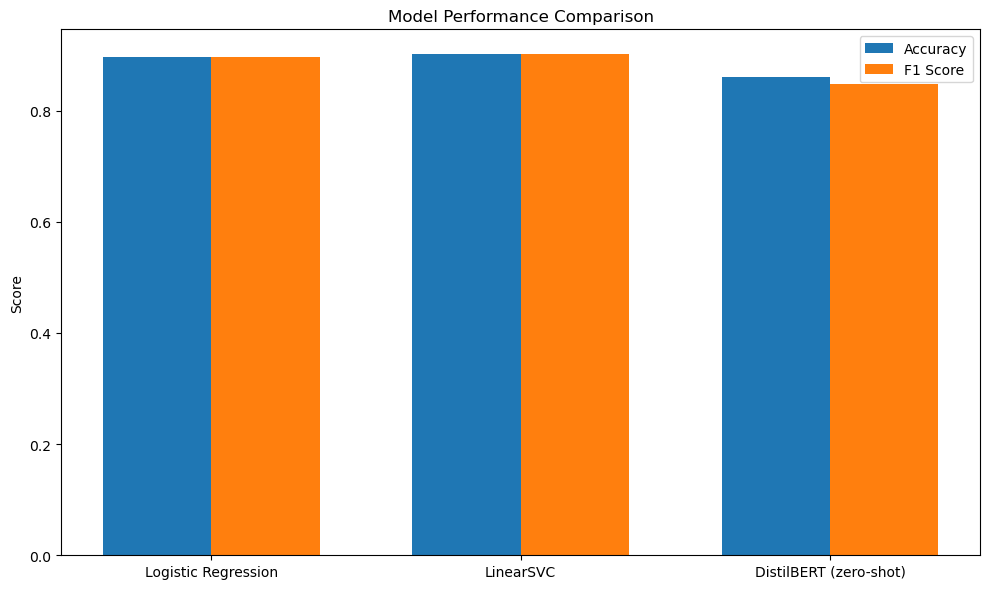

In [59]:
# Barchart comparisons for accuracy and F1 across Logistic Regression, LinearSVC, and DistilBERT
from sklearn.metrics import accuracy_score, f1_score

models = ['Logistic Regression', 'LinearSVC', 'DistilBERT (zero-shot)']
accuracies = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_SVC), accuracy_score(y_test[:1000], labels)]
f1_scores = [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_SVC), f1_score(y_test[:1000], labels)]

x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(10, 6))

plt.bar(x - width/2, accuracies, width, label='Accuracy')
plt.bar(x + width/2, f1_scores, width, label='F1 Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.legend()
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.savefig('../visuals/model_comparison.png')
plt.show()